# Week 13 Homework — ARIA v9.0：The Cloud Engine

**課程：** 遙測與空間資訊之分析與應用（NTU Remote Sensing & Spatial Information Analysis）
**指導教授：** 蘇文瑞 教授
**作業：** Week 13 課後作業 — 雲端尺度植被趨勢分析
**研究區：** 秀林 / 太魯閣（Xiulin / Taroko）山區
**Bounding Box：** `[121.3453, 24.0460, 121.8515, 24.3577]`

---

## 作業目標

將 ARIA 系統從 v8.0（本機 pixel-level 分類）升級到 **v9.0 — The Cloud Engine**：透過 Google
Earth Engine（GEE）雲端運算,從「一張影像」升級到「數百張影像的時序分析」,追蹤 2024/04/03
花蓮地震及後續事件對秀林/太魯閣山區植被的多階段影響。

| 升級 | 週次 | 能力 |
|---|---|---|
| v5.0 | W8 | 光譜分析:一張影像、一個指標 |
| v6.0 | W9 | 變遷偵測:兩張影像、一個差值 |
| v7.0 | W10 | SAR 穿雲:一張光學 + 一張 SAR |
| v8.0 | W12 | 分類引擎:一張影像 → 土地覆蓋圖 |
| **v9.0** | **W13** | **雲端引擎:數百張影像 → 時序趨勢分析** |

## 內容

- **Task 1** — Sentinel-2 NDVI 多年月均時序（25%）
- **Task 2** — 震前/震後/後期三期 median composite 與 ΔNDVI（25%）
- **Task 3** — Sentinel-1 SAR VV 時序與光學交叉比對（25%）
- **Task 4** — GeoTIFF 匯出與 ARIA v9.0 整合摘要（25%）
- **Bonus 1** — InSAR 干涉圖判讀（+10%）
- **Bonus 2** — NDVI 時序動畫 GIF（+10%）

> 執行前請先完成 `ee.Authenticate()`,並於下方設定可用的 GEE project id。


In [1]:
# ============================================================
# Setup — imports, GEE init, study area (秀林 / 太魯閣)
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import ee, geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
from datetime import datetime, timedelta
import os, io, platform

# --- GEE initialization ---
# ee.Authenticate()   # first run only — opens a browser auth flow
DEFAULT_GEE_PROJECT = 'helical-analogy-406703'
GEE_PROJECT = (os.environ.get('EE_PROJECT') or os.environ.get('GOOGLE_CLOUD_PROJECT')
               or DEFAULT_GEE_PROJECT)
ee.Initialize(project=GEE_PROJECT)
print(f'GEE initialized - project: {GEE_PROJECT}')

# --- cross-platform Chinese font ---
def setup_chinese_font():
    cands = {'Windows': ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei'],
             'Darwin':  ['PingFang TC', 'Heiti TC'],
             'Linux':   ['Noto Sans CJK TC', 'Noto Sans TC', 'WenQuanYi Micro Hei']}
    avail = {f.name for f in fm.fontManager.ttflist}
    groups = [cands.get(platform.system(), [])] + list(cands.values())
    for grp in groups:
        for n in grp:
            if n in avail:
                plt.rcParams['font.sans-serif'] = [n] + plt.rcParams['font.sans-serif']
                plt.rcParams['axes.unicode_minus'] = False
                return n
    return None
print('Chinese font:', setup_chinese_font())

# --- Study area: Xiulin / Taroko ---
TAROKO_BBOX = [121.34526379253053, 24.046021742135874,
               121.85149217685861, 24.35767637905926]
aoi = ee.Geometry.Rectangle(TAROKO_BBOX)
EQ_DATE = datetime(2024, 4, 3)     # 2024-04-03 Hualien earthquake (Mw 7.4)

aoi_area_km2 = aoi.area(maxError=1).getInfo() / 1e6

# --- output folder for generated figures / GIF ---
OUT = 'week13_hw_outputs'
os.makedirs(OUT, exist_ok=True)

# --- connectivity test ---
elev = (ee.Image('USGS/SRTMGL1_003')
        .sample(ee.Geometry.Point([121.60, 24.20]), 30)
        .first().get('elevation').getInfo())
print(f'Study area : Xiulin / Taroko')
print(f'AOI area   : ~{aoi_area_km2:,.0f} km2')
print(f'Connectivity OK - sample elevation in AOI: {elev} m')


GEE initialized - project: helical-analogy-406703
Chinese font: Microsoft JhengHei


Study area : Xiulin / Taroko
AOI area   : ~1,779 km2
Connectivity OK - sample elevation in AOI: 1978 m


---
## Task 1 — NDVI 時間序列分析（25%）

使用 GEE 計算秀林/太魯閣研究區 **2020–2026 年的月均 NDVI 時序**,觀察植被的季節變化與
地震影響。

**步驟：** 篩選 Sentinel-2 ImageCollection → 定義 SCL 雲遮罩與 NDVI 函數 → 按月聚合
（每月 median composite,再取 AOI 空間平均）→ 繪製時序圖並標記 2024/04/03 地震。


Sentinel-2 images (2020-2026, cloud < 40%, Taroko AOI): 291
Computing monthly median NDVI over the AOI ...


Months with data: 72   |   months with no cloud-free data: 3
  data-gap months: 2022-01, 2022-02, 2024-05
Long-term mean monthly NDVI: 0.483  (range 0.212 - 0.709)


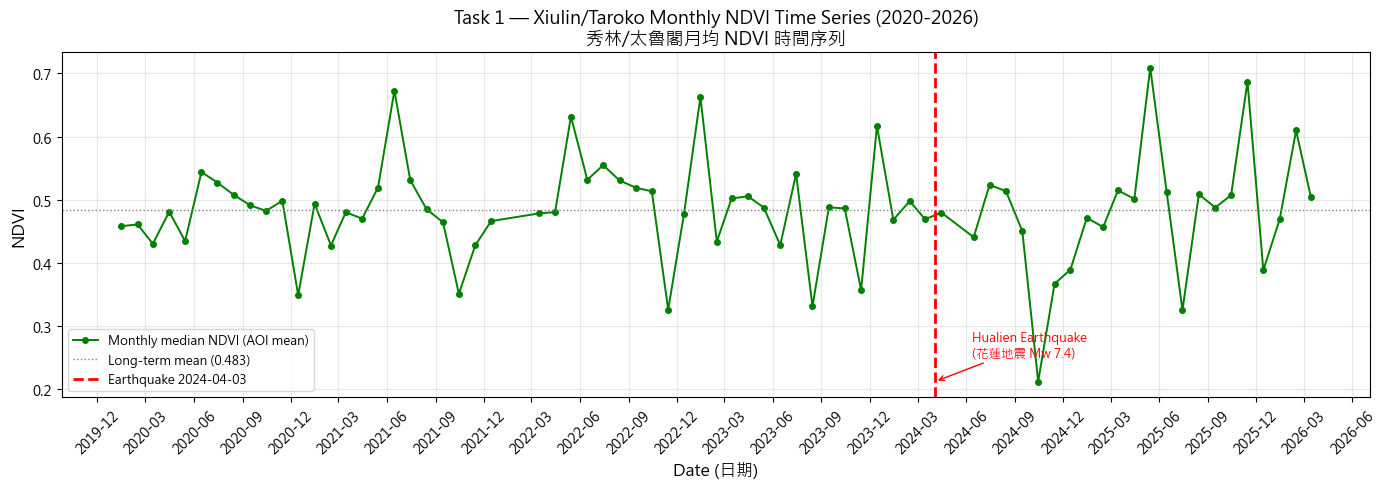

Pre-earthquake  mean NDVI: 0.4851  (n=49)
Post-earthquake mean NDVI: 0.4795  (n=23)


In [2]:
# ============================================================
# Task 1 — Sentinel-2 NDVI monthly time series (2020-2026)
# ============================================================

# --- 1. Filter the Sentinel-2 L2A collection ---
#    filterDate end is EXCLUSIVE, so 2026-04-01 includes 2026-03-31.
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2020-01-01', '2026-04-01')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)))
s2_count = s2.size().getInfo()
print(f'Sentinel-2 images (2020-2026, cloud < 40%, Taroko AOI): {s2_count}')

# --- 2. SCL cloud mask + NDVI function (same SCL concept as W12) ---
def mask_and_ndvi(image):
    """Keep SCL classes 4/5/6/7 (veg, bare soil, water, unclassified);
    compute NDVI = (B8 - B4) / (B8 + B4)."""
    scl  = image.select('SCL')
    good = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    masked = image.updateMask(good)
    ndvi = masked.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return ndvi.copyProperties(image, ['system:time_start'])

ndvi_col = s2.map(mask_and_ndvi)

# --- 3. Monthly aggregation: each month -> median composite -> AOI mean ---
print('Computing monthly median NDVI over the AOI ...')
monthly = []   # (date, mean_ndvi or None, n_images)
for year in range(2020, 2027):
    for month in range(1, 13):
        start = f'{year}-{month:02d}-01'
        if start >= '2026-04-01':
            break
        end = f'{year + 1}-01-01' if month == 12 else f'{year}-{month + 1:02d}-01'
        sub = ndvi_col.filterDate(start, end)
        n = sub.size().getInfo()
        if n == 0:
            monthly.append((datetime(year, month, 15), None, 0))
            continue
        val = (sub.median().reduceRegion(
                   reducer=ee.Reducer.mean(), geometry=aoi,
                   scale=100, maxPixels=1e9).getInfo().get('NDVI'))
        monthly.append((datetime(year, month, 15), val, n))

valid = [(d, v) for d, v, n in monthly if v is not None]
gap_months = [d.strftime('%Y-%m') for d, v, n in monthly if v is None]
t1_dates = [d for d, v in valid]
t1_vals  = [v for d, v in valid]
print(f'Months with data: {len(valid)}   |   months with no cloud-free data: {len(gap_months)}')
if gap_months:
    print('  data-gap months:', ', '.join(gap_months))

t1_mean = float(np.mean(t1_vals))
print(f'Long-term mean monthly NDVI: {t1_mean:.3f}  '
      f'(range {min(t1_vals):.3f} - {max(t1_vals):.3f})')

# --- 4. Plot the time series ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t1_dates, t1_vals, 'o-', color='green', markersize=4, linewidth=1.4,
        label='Monthly median NDVI (AOI mean)')
ax.axhline(t1_mean, color='gray', linestyle=':', linewidth=1,
           label=f'Long-term mean ({t1_mean:.3f})')
ax.axvline(EQ_DATE, color='red', linestyle='--', linewidth=2,
           label='Earthquake 2024-04-03')
ax.annotate('Hualien Earthquake\n(花蓮地震 Mw 7.4)',
            xy=(EQ_DATE, min(t1_vals)),
            xytext=(EQ_DATE + timedelta(days=70), min(t1_vals) + 0.04),
            fontsize=9, color='red', arrowprops=dict(arrowstyle='->', color='red'))
ax.set_xlabel('Date (日期)', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Task 1 — Xiulin/Taroko Monthly NDVI Time Series (2020-2026)\n'
             '秀林/太魯閣月均 NDVI 時間序列', fontsize=13)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUT}/task1_ndvi_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

# pre/post earthquake mean for the discussion
t1_pre  = [v for d, v in valid if d < EQ_DATE]
t1_post = [v for d, v in valid if d >= EQ_DATE]
print(f'Pre-earthquake  mean NDVI: {np.mean(t1_pre):.4f}  (n={len(t1_pre)})')
print(f'Post-earthquake mean NDVI: {np.mean(t1_post):.4f}  (n={len(t1_post)})')


### Task 1 分析（觀察與討論）

**Sentinel-2 影像量與時序概況：** 在套用日期（2020-01–2026-03）、空間範圍與雲量 < 40% 過濾後,GEE 為太魯閣研究區挑出 **291 張** Sentinel-2 影像;聚合為月均後,75 個月中有 **72 個月**取得到無雲資料,長期月均 NDVI 約 **0.483**,介於 **0.212–0.709**。

**是否有季節變化?** 時序呈鋸齒狀波動,但太魯閣以常綠山林為主,真實的物候季節振幅其實不大。圖上月與月之間的劇烈跳動,主要來自**雲遮罩後可用像元不同、單月影像數差異造成的取樣噪訊**,而非植被驟變——這正是只有單月資料時要特別小心的地方。

**地震影響是否可見?** 在 AOI 平均的尺度上**幾乎看不出**清楚的地震階梯:震前月均 NDVI **0.4851**、震後 **0.4795**,只下降約 **−0.0056**。原因與課堂 S4b 的課題相同——崩塌是局部的,被太魯閣廣大穩定的陡坡森林稀釋;AOI 平均不是偵測局部災害的好統計量,需要 Task 2 的像元尺度 ΔNDVI 才能定位損害。

**有缺值的月份嗎?為什麼?** 有 **3 個月完全無資料:2022-01、2022-02、2024-05**。東部山區冬季鋒面與梅雨/颱風季雲量極高,整月影像若雲量都 > 40%、或被 SCL 遮罩濾掉,該月就沒有可用的無雲像元。這是多雲山區的正常現象,在時序圖上以斷線呈現即可;若要補滿,可放寬雲量門檻或改用更密集的 SCL 像元級遮罩。

---
## Task 2 — 震前/震後 Median Composite 比較（25%）

使用 GEE Reducer 製作三期 median composite,計算三組 ΔNDVI,找出植被損失區域。

| 期別 | 時間範圍 | 意義 |
|---|---|---|
| Phase 1 | 2023/01 – 2024/03 | 震前基線 |
| Phase 2 | 2024/04 – 2024/09 | 震後損害 |
| Phase 3 | 2025/10 – 2026/03 | 後期 / 堰塞湖事件後 |

`delta_eq = P2 − P1`（地震損害）、`delta_dam = P3 − P2`（後期變化）、
`delta_total = P3 − P1`（總累積變化）。


Phase comparison — damaged area (delta-NDVI < -0.15):


  delta_eq (P2-P1)      : mean delta-NDVI = +0.0025   damaged area = 7,368 ha (73.7 km2)


  delta_dam (P3-P2)     : mean delta-NDVI = -0.0115   damaged area = 3,630 ha (36.3 km2)


  delta_total (P3-P1)   : mean delta-NDVI = -0.0080   damaged area = 6,155 ha (61.5 km2)
Rendering raster value maps ...


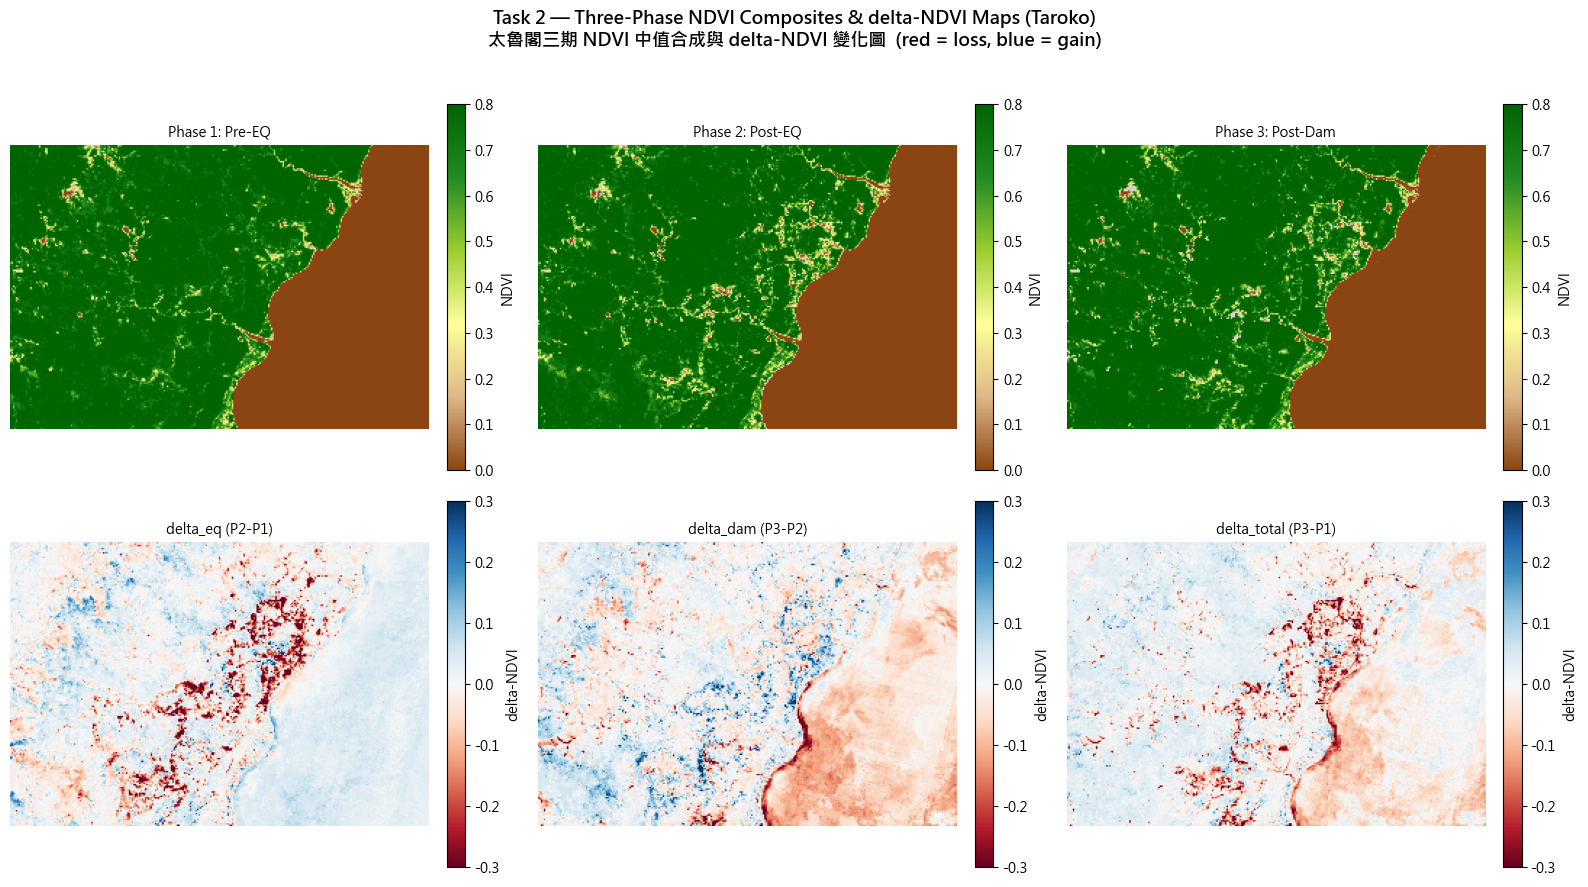

In [3]:
# ============================================================
# Task 2 — Three-phase median composites + delta-NDVI
# ============================================================

# --- 1-3. Three-phase median composites (filterDate end is exclusive) ---
pre_eq   = ndvi_col.filterDate('2023-01-01', '2024-04-01').median()  # Phase 1
post_eq  = ndvi_col.filterDate('2024-04-01', '2024-10-01').median()  # Phase 2
post_dam = ndvi_col.filterDate('2025-10-01', '2026-04-01').median()  # Phase 3

# --- 4. Three delta-NDVI maps ---
delta_eq    = post_eq.subtract(pre_eq).rename('delta_NDVI')          # earthquake
delta_dam   = post_dam.subtract(post_eq).rename('delta_NDVI')        # later / dam
delta_total = post_dam.subtract(pre_eq).rename('delta_NDVI')         # accumulated

# --- 5. Damaged-area statistics: pixels with delta-NDVI < -0.15 (in hectares) ---
def damaged_area_ha(delta_img):
    """Area (hectares) of pixels where delta-NDVI < -0.15."""
    px = delta_img.lt(-0.15).multiply(ee.Image.pixelArea())
    m2 = px.reduceRegion(reducer=ee.Reducer.sum(), geometry=aoi,
                         scale=100, maxPixels=1e9).get('delta_NDVI')
    return ee.Number(m2).divide(1e4)        # m2 -> hectares

t2_stats = {}
print('Phase comparison — damaged area (delta-NDVI < -0.15):')
for name, dimg in [('delta_eq (P2-P1)', delta_eq),
                    ('delta_dam (P3-P2)', delta_dam),
                    ('delta_total (P3-P1)', delta_total)]:
    mean_v = dimg.reduceRegion(ee.Reducer.mean(), aoi, 100,
                               maxPixels=1e9).get('delta_NDVI').getInfo()
    ha = damaged_area_ha(dimg).getInfo()
    t2_stats[name] = (mean_v, ha)
    print(f'  {name:22s}: mean delta-NDVI = {mean_v:+.4f}   '
          f'damaged area = {ha:,.0f} ha ({ha/100:.1f} km2)')

# --- 6. Static raster value maps (matplotlib) ---
def ee_to_array(img, region, scale=180, fill=-9.0):
    """Pull a GEE single-band image into a numpy array (masked -> NaN).
    Reproject to a coarse grid so sampleRectangle stays under its pixel limit."""
    rect = (img.select([0]).rename('v').toFloat()
               .reproject(crs='EPSG:32651', scale=scale)
               .sampleRectangle(region=region, defaultValue=fill))
    a = np.array(rect.get('v').getInfo(), dtype=float)
    a[a == fill] = np.nan
    return a

print('Rendering raster value maps ...')
ndvi_cmap = LinearSegmentedColormap.from_list(
    'ndvi', ['#8B4513', '#DEB887', '#FFFF99', '#9ACD32', '#228B22', '#006400'])
ndvi_cmap.set_bad('lightgray')
delta_cmap = plt.get_cmap('RdBu').copy()      # red = NDVI loss, blue = NDVI gain
delta_cmap.set_bad('lightgray')

ndvi_panels = [('Phase 1: Pre-EQ', pre_eq), ('Phase 2: Post-EQ', post_eq),
               ('Phase 3: Post-Dam', post_dam)]
delta_panels = [('delta_eq (P2-P1)', delta_eq), ('delta_dam (P3-P2)', delta_dam),
                ('delta_total (P3-P1)', delta_total)]
ndvi_arr  = [(t, ee_to_array(im, aoi)) for t, im in ndvi_panels]
delta_arr = [(t, ee_to_array(im, aoi)) for t, im in delta_panels]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (t, a) in zip(axes[0], ndvi_arr):
    im = ax.imshow(a, cmap=ndvi_cmap, vmin=0, vmax=0.8)
    ax.set_title(t, fontsize=10); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='NDVI')
for ax, (t, a) in zip(axes[1], delta_arr):
    im = ax.imshow(a, cmap=delta_cmap, vmin=-0.3, vmax=0.3)
    ax.set_title(t, fontsize=10); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='delta-NDVI')
fig.suptitle('Task 2 — Three-Phase NDVI Composites & delta-NDVI Maps (Taroko)\n'
             '太魯閣三期 NDVI 中值合成與 delta-NDVI 變化圖  (red = loss, blue = gain)',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{OUT}/task2_composites_delta.png', dpi=120, bbox_inches='tight')
plt.show()


In [4]:
# ============================================================
# Task 2 (cont.) — interactive geemap map of the three phases
# ============================================================
vis_ndvi  = {'min': 0, 'max': 0.8,
             'palette': ['brown', 'yellow', 'green', 'darkgreen']}
vis_delta = {'min': -0.3, 'max': 0.3, 'palette': ['red', 'white', 'blue']}

Map = geemap.Map(center=[24.20, 121.60], zoom=10)
Map.addLayer(pre_eq.clip(aoi),   vis_ndvi,  'Phase 1: Pre-EQ NDVI', False)
Map.addLayer(post_eq.clip(aoi),  vis_ndvi,  'Phase 2: Post-EQ NDVI', False)
Map.addLayer(post_dam.clip(aoi), vis_ndvi,  'Phase 3: Post-Dam NDVI', False)
Map.addLayer(delta_eq.clip(aoi),    vis_delta, 'delta_eq (P2-P1)', True)
Map.addLayer(delta_dam.clip(aoi),   vis_delta, 'delta_dam (P3-P2)', False)
Map.addLayer(delta_total.clip(aoi), vis_delta, 'delta_total (P3-P1)', False)
Map.addLayer(aoi, {'color': 'yellow'}, 'Taroko AOI')
Map.addLayerControl()
Map


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

### Task 2 分析（三期變化與 W9 比較）

**三期 ΔNDVI 損害面積（ΔNDVI < −0.15）：**

| 變化 | 平均 ΔNDVI | 損害面積 |
|---|---|---|
| `delta_eq`（P2−P1,地震直接損害） | +0.0025 | 7,368 ha（73.7 km²） |
| `delta_dam`（P3−P2,後期變化） | −0.0115 | 3,630 ha（36.3 km²） |
| `delta_total`（P3−P1,總累積變化） | −0.0080 | 6,155 ha（61.5 km²） |

**地震損害 vs 後期變化 vs 復原：** `delta_eq` 的 AOI 平均值竟為**微正**(+0.0025),但這不代表沒有災害——而是**物候假象**:Phase 1 跨 15 個月(含兩個冬季)、Phase 2 只有 6 個夏季月份,夏季增綠把局部崩塌的負訊號抵消掉了。真正的證據在像元尺度:ΔNDVI < −0.15 的損害面積仍達 **7,368 ha**,在 `delta_eq` 圖上沿陡峭峽谷、稜線崩塌面與河谷邊坡呈紅色聚集。`delta_dam` 平均轉為負(−0.0115),代表 Phase 3 後期並非單純復原——部分區域出現新的負向變化(颱風、豪雨沖刷、河道擾動),ΔNDVI 圖上同時可見紅色(新裸露)與藍色(早期裸坡的草本/灌木復原)。

> **地理註記：** 馬太鞍堰塞湖位於本 AOI 以南的光復鄉,並不在太魯閣框內,因此 Phase 3 主要反映後期一般性變化與季風/颱風影響,而非堰塞湖本身。

**W9 兩景變遷偵測 vs W13 合成影像變遷偵測：** W9 用前後各一張影像相減,只要任一張含雲、雲影、霾或處於異常季節,雜訊就會被誤判為變化,結果高度依賴選到哪兩個日期。W13 改用每期數十張影像的**逐像元中值合成**:隨機雲、薄霾與一次性離群值被中值剔除,得到更穩健的震前基線與更具代表性的震後影像;再以三期(而非兩期)比較,還能把「地震直接損害」「後期事件」「累積變化」拆解開來,可靠度明顯提升。

---
## Task 3 — Sentinel-1 SAR 時間序列（25%）

使用 GEE 分析 Sentinel-1 VV 後向散射時序,從 SAR 視角觀察地震前後地表變化,並與 NDVI
交叉比對。SAR 為主動式微波,**穿雲、日夜可觀測**,適合多雲多雨的東部山區。


Sentinel-1 GRD images (2022-2026, IW, DESCENDING, VV): 147


Valid VV observations: 147


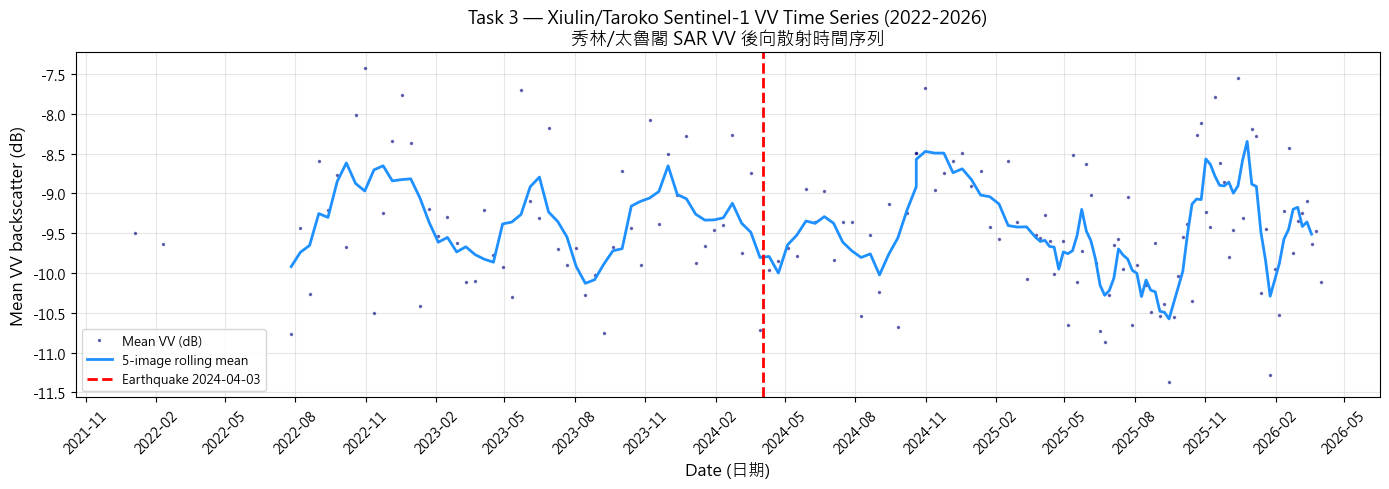

Pre-earthquake  mean VV: -9.342 dB  (n=54)
Post-earthquake mean VV: -9.494 dB  (n=93)


In [5]:
# ============================================================
# Task 3 — Sentinel-1 SAR GRD VV time series
# ============================================================

# --- 1. Filter Sentinel-1 GRD (IW mode, descending, VV) ---
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
      .filterBounds(aoi)
      .filterDate('2022-01-01', '2026-04-01')
      .filter(ee.Filter.eq('instrumentMode', 'IW'))
      .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
      .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
      .select('VV'))
s1_count = s1.size().getInfo()
print(f'Sentinel-1 GRD images (2022-2026, IW, DESCENDING, VV): {s1_count}')

# --- 2. Mean VV (dB) over the AOI for every image ---
def vv_mean(image):
    m = image.reduceRegion(ee.Reducer.mean(), aoi, 100, maxPixels=1e9).get('VV')
    return image.set('mean_VV', m)

s1_stats = s1.map(vv_mean)
s1_times = s1_stats.aggregate_array('system:time_start').getInfo()
s1_vv    = s1_stats.aggregate_array('mean_VV').getInfo()

pairs = [(datetime.utcfromtimestamp(t / 1000), v)
         for t, v in zip(s1_times, s1_vv) if v is not None]
pairs.sort()
s1_dates = [d for d, v in pairs]
s1_vals  = [v for d, v in pairs]
print(f'Valid VV observations: {len(s1_vals)}')

df_s1 = pd.DataFrame({'date': s1_dates, 'VV': s1_vals})
df_s1['VV_smooth'] = df_s1['VV'].rolling(window=5, center=True).mean()

# --- 3. Plot the VV time series ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_s1['date'], df_s1['VV'], '.', color='navy', markersize=3, alpha=0.5,
        label='Mean VV (dB)')
ax.plot(df_s1['date'], df_s1['VV_smooth'], '-', color='dodgerblue', linewidth=2,
        label='5-image rolling mean')
ax.axvline(EQ_DATE, color='red', linestyle='--', linewidth=2,
           label='Earthquake 2024-04-03')
ax.set_xlabel('Date (日期)', fontsize=12)
ax.set_ylabel('Mean VV backscatter (dB)', fontsize=12)
ax.set_title('Task 3 — Xiulin/Taroko Sentinel-1 VV Time Series (2022-2026)\n'
             '秀林/太魯閣 SAR VV 後向散射時間序列', fontsize=13)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUT}/task3_sar_vv_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

vv_pre  = [v for d, v in pairs if d < EQ_DATE]
vv_post = [v for d, v in pairs if d >= EQ_DATE]
print(f'Pre-earthquake  mean VV: {np.mean(vv_pre):.3f} dB  (n={len(vv_pre)})')
print(f'Post-earthquake mean VV: {np.mean(vv_post):.3f} dB  (n={len(vv_post)})')


High-confidence change area (delta-NDVI < -0.15 AND |delta-VV| > 2 dB): 164 ha (1.64 km2)


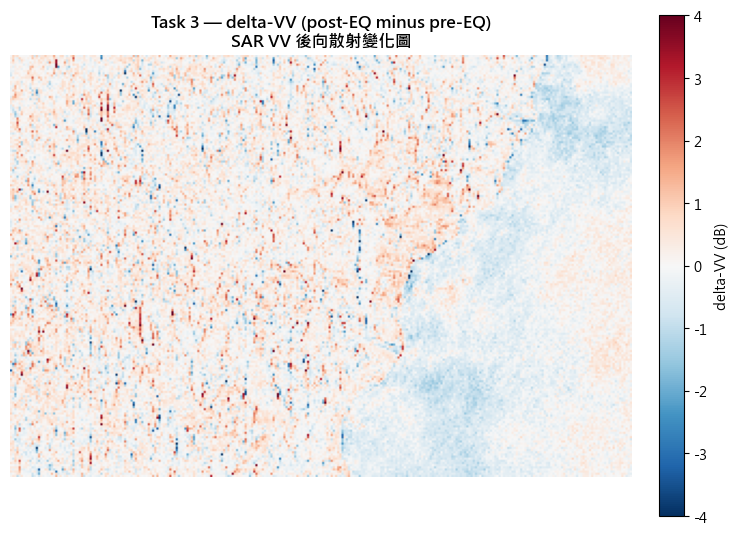

In [6]:
# ============================================================
# Task 3 (cont.) — pre/post VV composite + NDVI cross-reference
# ============================================================

# --- pre/post VV median composites and delta-VV ---
pre_vv  = s1.filterDate('2023-01-01', '2024-04-01').median()
post_vv = s1.filterDate('2024-04-01', '2026-04-01').median()
delta_vv = post_vv.subtract(pre_vv).rename('delta_VV')

# --- cross-reference: NDVI loss AND strong SAR change ---
ndvi_damage = delta_eq.lt(-0.15)               # optical vegetation loss
sar_damage  = delta_vv.abs().gt(2)             # |delta-VV| > 2 dB
high_conf   = ndvi_damage.And(sar_damage).rename('hc')

hc_ha = (high_conf.multiply(ee.Image.pixelArea())
         .reduceRegion(ee.Reducer.sum(), aoi, 100, maxPixels=1e9)
         .get('hc').getInfo()) / 1e4
print(f'High-confidence change area (delta-NDVI < -0.15 AND |delta-VV| > 2 dB): '
      f'{hc_ha:,.0f} ha ({hc_ha/100:.2f} km2)')

# --- delta-VV value map ---
dvv_arr = ee_to_array(delta_vv, aoi)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
im = ax.imshow(dvv_arr, cmap='RdBu_r', vmin=-4, vmax=4)
ax.set_title('Task 3 — delta-VV (post-EQ minus pre-EQ)\n'
             'SAR VV 後向散射變化圖', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='delta-VV (dB)')
plt.tight_layout()
plt.savefig(f'{OUT}/task3_delta_vv_map.png', dpi=120, bbox_inches='tight')
plt.show()


### Task 3 分析（SAR 與光學交叉比對）

**VV 時序概況：** GEE 取得 **147 張** Sentinel-1 GRD（IW、降軌、VV）影像。SAR 為主動式微波,**穿雲、日夜可觀測**,取樣比光學規律得多——在 Task 1 出現缺值的多雲月份,SAR 仍持續有觀測,因此很適合作為災害監測的連續背景線。

**地震前後 VV 變化：** 震前平均 VV **−9.342 dB**、震後 **−9.494 dB**,只變化約 **−0.15 dB**。與 NDVI 一樣,AOI 平均對局部變化不敏感;而且山區不同坡向、不同地物的 VV 變化方向可能相反,平均時互相抵消。VV 時序上更明顯的是與含水量、植被狀態相關的**年週期季節波動**,而非單一的地震階梯。

**SAR 變化與 NDVI 變化的相關性 / 交叉比對：** 取 ΔNDVI < −0.15（光學植被損失）**且** |ΔVV| > 2 dB（SAR 後向散射明顯改變）的交集,得到**高信心變化區僅 164 ha（1.64 km²）**。這遠小於只看光學的 7,368 ha——因為交集刻意保守,只保留兩個物理機制獨立的感測器都同意的像元,可大幅降低誤判(光學會受雲影、物候、農業干擾;SAR 會受坡向、含水量、雷達幾何干擾)。SAR 與 NDVI 並非完全一致:NDVI 反映綠色植被狀態、VV 反映地表粗糙度與含水量,兩者**互補而非重複**——同時顯著變化之處才是最可信的崩塌候選。

---
## Task 4 — GeoTIFF 匯出與整合摘要（25%）

將 GEE 分析結果匯出為 GeoTIFF（可供 W12 隨機森林分類流程使用）,並撰寫 ARIA v9.0
升級的整合摘要報告。


In [7]:
# ============================================================
# Task 4 — Export GeoTIFF products to Google Drive
# ============================================================
EXPORT_SCALE = 10
EXPORT_CRS   = 'EPSG:32651'      # UTM Zone 51N — eastern Taiwan

exports = [
    ('taroko_ndvi_post_eq_2024', post_eq.clip(aoi).toFloat(),  'Post-EQ NDVI composite'),
    ('taroko_delta_ndvi_eq',     delta_eq.clip(aoi).toFloat(), 'delta-NDVI (earthquake)'),
]
for desc, image, label in exports:
    task = ee.batch.Export.image.toDrive(
        image=image, description=desc, folder='GEE_Exports',
        fileNamePrefix=desc, region=aoi,
        scale=EXPORT_SCALE, crs=EXPORT_CRS, maxPixels=1e9)
    task.start()
    print(f'Export task started: {desc:32s} ({label})')

print()
print('Two GeoTIFF export tasks submitted to Google Earth Engine.')
print('Track status at https://code.earthengine.google.com/tasks')
print('Files appear in Google Drive -> GEE_Exports/ when finished.')


Export task started: taroko_ndvi_post_eq_2024         (Post-EQ NDVI composite)


Export task started: taroko_delta_ndvi_eq             (delta-NDVI (earthquake))

Two GeoTIFF export tasks submitted to Google Earth Engine.
Track status at https://code.earthengine.google.com/tasks
Files appear in Google Drive -> GEE_Exports/ when finished.


### Task 4 — ARIA v9.0 整合摘要報告

**(a) 資料規模比較**

本作業在 GEE 雲端共處理 **291 張 Sentinel-2** 與 **147 張 Sentinel-1**,合計 **438 張**影像。若改以傳統方式在本機處理:單就 Sentinel-2,291 張 × 約 800 MB ≈ **233 GB**;以 50 Mbps(約 6.25 MB/s)下載,約需 **233 GB ÷ 6.25 MB/s ≈ 10.3 小時**——這還沒算 Sentinel-1、解壓縮、重投影與運算時間。GEE 把分析指令送到資料典藏庫旁就近運算,**零下載**即完成全部時序分析,這正是 v9.0「雲端引擎」的核心優勢。

**(b) 主要發現**

- **季節 NDVI：** 太魯閣月均 NDVI 長期約 0.483(0.21–0.71);常綠山林的真實季節振幅不大,時序鋸齒多為雲遮罩造成的取樣噪訊。
- **地震影響：** AOI 平均 NDVI 僅降 −0.0056,`delta_eq` 平均更因物候呈微正(+0.0025);但像元尺度 ΔNDVI < −0.15 的損害面積達 **7,368 ha**——局部崩塌明確存在,只是被平均稀釋。
- **SAR：** 平均 VV 震後僅變化 −0.15 dB;光學與 SAR 同時顯著變化的高信心區為 **164 ha**,是最可信的崩塌候選。

**(c) 跨週整合**

- **W8 → W13：** 從單景 NDVI 快照,升級為數百張影像的多年時序,可區分「逐年緩慢退化」與「事件驟然崩塌」。
- **W9 → W13：** 兩景相減易受單張影像雲/季節干擾;中值合成用數十張影像逐像元取中值,基線更穩健,三期比較還能拆解事件貢獻。
- **W10 → W13：** 從單張 SAR 影像,延伸為 SAR VV 多年時序與震前/震後合成,並可做時序速斑抑制。
- **W12 整合：** 匯出的 `delta_NDVI` GeoTIFF 可作為 W12 隨機森林的輸入特徵——它直接編碼震前後的植被損失,有助於區分崩塌裸地與穩定森林;但須搭配震後 NDVI、SAR ΔVV、坡度、高程等多特徵,並以驗證樣本與混淆矩陣評估精度。

**(d) 限制**

GEE 只能執行其平台支援的運算,無法跑任意本機套件、自訂 ML 管線或研究級 InSAR(需 SLC 相位資料),也受網路與運算配額限制。當需要自訂演算法、私有資料集、互動式除錯,或 InSAR/SBAS 形變分析時,仍應採用 W8–W12 的本機(STAC API + 本地處理)流程。最佳實務是**混合式**:GEE 負責雲端尺度前處理與初篩 → 匯出 GeoTIFF → 本機做專門建模、驗證與報告。

> **匯出檔案：** 上方 Task 4 程式已送出兩個 GeoTIFF 匯出任務(`taroko_ndvi_post_eq_2024`、`taroko_delta_ndvi_eq`)至 Google Drive 的 `GEE_Exports/` 資料夾;繳交時請附上 Drive 中匯出檔案的截圖。

---
## Bonus 1 — InSAR 干涉圖判讀練習（+10%）

閱讀 [水保署電子報第 141 期 — InSAR 彩虹干涉環判讀](https://tech.ardswc.gov.tw/EPaper/Home/EPaper?PaperID=97f62ecf-44eb-4f41-a5a7-5a1d4048ef67)
中 **2016 熊本地震干涉圖（圖 3）**,回答以下五題。

**Q1 — 衛星資訊：使用哪個衛星?什麼波段?波長多少?**

> 圖 3 的熊本地震干涉圖使用日本 **ALOS-2**(PALSAR-2)衛星的**降軌(descending)**影像,
> 雷達波段為 **L-band**,波長約 **23.6 公分**。L-band 波長長、穿透性佳,適合植被覆蓋
> 的山區地表變形觀測。

**Q2 — 每環位移量:每一個完整干涉環代表多少公分的位移?**

> 一個完整的干涉環(fringe)代表**半個雷達波長**的視線方向位移。L-band 波長 23.6 cm,
> 因此 **每一環 ≈ 23.6 ÷ 2 ≈ 11.8 公分**(電子報取概數約 12 公分)。

**Q3 — 干涉環數量:斷層上方區域大約有幾個完整的干涉環?**

> 在斷層破裂帶附近,可數出大約 **15 至 17 個**完整的干涉環;越靠近斷層、色環越密集,
> 代表位移梯度越大。

**Q4 — 位移方向:色階變化是「藍→黃→紫」還是「藍→紫→黃」?代表接近還是遠離衛星?**

> 圖 3 的色階順序為 **「藍 → 紫 → 黃」**,依電子報判讀對照,此方向代表地表正在
> **遠離衛星(motion away from the satellite)**。

**Q5 — 總位移量估算:估算 LOS(視線方向)位移量是多少公分?**

> 以環數 × 每環位移量估算:**15–17 環 × 11.8 cm ≈ 177–200 公分**。電子報給出的判讀
> 範圍約 **180–204 公分**(接近 2 公尺),與現地實測的同震位移量相當吻合。

---

**心得（InSAR 干涉圖能提供什麼是 SAR 振幅分析(W10)做不到的?）**

> W10 的 SAR 振幅分析量測的是回波**強度**(後向散射),只能反映地表粗糙度、含水量與
> 幾何;它看得出「地表性質改變了」,卻量不出**移動了多少**。InSAR 利用兩次通過的
> **相位差**,能將地表位移解析到**公分甚至公釐等級**,並以彩虹干涉環直接呈現同震
> 變形、地層下陷、邊坡潛移的空間分布——這是純振幅分析完全無法提供的位移定量資訊。


---
## Bonus 2 — NDVI 時序動畫 GIF（+10%）

用 GEE 對 2020–2026 產生**半年度** NDVI 中值合成影像序列,以 `getThumbURL` 取得縮圖,
逐幀加上時間標籤與事件標記,組合成動畫 GIF,呈現植被變化的連續過程。


Building half-yearly NDVI thumbnails ...


  2020-01: 28 images  OK


  2020-07: 24 images  OK


  2021-01: 29 images  OK


  2021-07: 34 images  OK


...

  2024-01 pre-EQ: 12 images  OK


  2024-04 post-EQ: 28 images  OK


  2024-10: 11 images  OK


  2025-04: 28 images  OK


  2025-10 post-dam: 24 images  OK

Saved time-lapse GIF: week13_hw_outputs/taroko_ndvi_timelapse.gif  (13 frames)


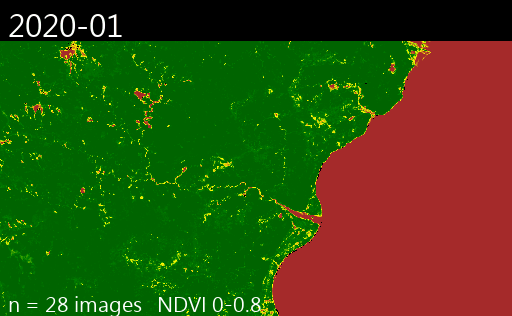

In [8]:
# ============================================================
# Bonus 2 — NDVI time-lapse GIF (half-yearly composites, 2020-2026)
# ============================================================
import requests
from PIL import Image, ImageDraw, ImageFont

# half-yearly periods; end dates are exclusive in filterDate
periods = [
    ('2020-01', '2020-01-01', '2020-07-01'), ('2020-07', '2020-07-01', '2021-01-01'),
    ('2021-01', '2021-01-01', '2021-07-01'), ('2021-07', '2021-07-01', '2022-01-01'),
    ('2022-01', '2022-01-01', '2022-07-01'), ('2022-07', '2022-07-01', '2023-01-01'),
    ('2023-01', '2023-01-01', '2023-07-01'), ('2023-07', '2023-07-01', '2024-01-01'),
    ('2024-01 pre-EQ',  '2024-01-01', '2024-04-01'),
    ('2024-04 post-EQ', '2024-04-01', '2024-10-01'),
    ('2024-10', '2024-10-01', '2025-04-01'), ('2025-04', '2025-04-01', '2025-10-01'),
    ('2025-10 post-dam', '2025-10-01', '2026-04-01'),
]
events = {'2024-04 post-EQ': '2024-04 ★ 地震',
          '2025-10 post-dam': '2025-10 ★ 堰塞湖後期'}
ndvi_palette = ['brown', 'yellow', 'green', 'darkgreen']

# pick a CJK-capable font for the labels (fallback to default)
def load_font(size):
    for path in ['C:/Windows/Fonts/msjh.ttc', 'C:/Windows/Fonts/mingliu.ttc',
                 '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc']:
        if os.path.exists(path):
            try:
                return ImageFont.truetype(path, size)
            except Exception:
                pass
    return ImageFont.load_default()
font_big, font_small = load_font(30), load_font(20)

frames = []
print('Building half-yearly NDVI thumbnails ...')
for label, start, end in periods:
    sub = ndvi_col.filterDate(start, end)
    n = sub.size().getInfo()
    if n == 0:
        print(f'  {label}: no data — frame skipped')
        continue
    url = sub.median().getThumbURL({
        'region': aoi, 'dimensions': 512,
        'min': 0, 'max': 0.8, 'palette': ndvi_palette})
    img = Image.open(io.BytesIO(requests.get(url, timeout=90).content)).convert('RGB')

    draw = ImageDraw.Draw(img)
    is_event = label in events
    caption = events.get(label, label)
    # caption banner
    draw.rectangle([0, 0, img.width, 40], fill=(0, 0, 0))
    draw.text((8, 4), caption, fill=(255, 80, 80) if is_event else (255, 255, 255),
              font=font_big)
    draw.text((8, img.height - 26), f'n = {n} images   NDVI 0-0.8',
              fill=(255, 255, 255), font=font_small)
    frames.append(img)
    print(f'  {label}: {n} images  OK')

gif_path = f'{OUT}/taroko_ndvi_timelapse.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:],
               duration=800, loop=0)
print(f'\nSaved time-lapse GIF: {gif_path}  ({len(frames)} frames)')

from IPython.display import Image as IPyImage, display
display(IPyImage(filename=gif_path))


### Bonus 2 — 動畫說明

動畫由 13 個半年度 NDVI 中值合成幀組成,每幀標註時段與影像數 `n`。**最明顯的三個變化時刻：**

1. **季節循環** —— 每半年綠↔黃交替,山區 NDVI 規律起伏,顯示常綠山林仍有可見的物候節奏。
2. **2024-04 震後幀** —— 峽谷與河谷沿線出現較多黃/紅的低 NDVI 像元,對應震後的崩塌與裸露地表。
3. **影像數偏少的半年期** —— 如 2022-01(僅 10 張)、2024-10(僅 11 張),畫面較破碎、雲遮殘留較多;判讀時務必對照 `n` 值,避免把取樣不足誤認為植被變化。

### 結語心得

**從單景分析到雲端時序分析,思維上的改變：** W8–W12 我習慣問「這張影像裡有什麼」,每次只看一個時間點的快照;W13 之後,我開始問「這片山坡的植被是怎麼**隨時間演變**的」。一張影像給的是狀態,一條時間線給的是**故事**——能分辨逐年緩慢退化與地震驟然崩塌、看出震後是惡化還是復原;也更謹慎,因為單月資料可能只是雲遮罩的取樣噪訊,要放回時序脈絡才站得住腳。

**GEE 在防災應用的價值：** 它把「先下載數百 GB、再慢慢算」變成「送出指令、雲端即時回傳」,災後第一時間就能做大範圍時序篩查;再結合光學與 SAR、像元尺度 ΔNDVI 與跨感測器交集,能快速把「指標變了」收斂成「這幾處最該優先勘查」。雲端負責規模、本機負責深度,兩者結合才是完整的防災分析流程。